# CAT12 cohort throughput — last-modified-file timestamps

Exploratory only — no outputs committed (nbstripout). Answers "how fast is a
`bag preprocess cat12-cohort` run actually going" from real filesystem
timestamps, not the ledger's own bookkeeping — a genuinely independent check
(the ledger records when the *driver* marked a subject done; this notebook
looks at when CAT12 itself last touched a file on disk for that subject).

Method: for every subject/session under `output_derivatives_dir`
(`config/cat12_cohort.yaml`), find the single most-recently-modified file
anywhere in that session's output tree — CAT12 writes dozens of files per
subject and finishes with the QC/report XML, so the max mtime across all of
them is a good proxy for "when this subject finished."

**Real gotcha, found running this against the live 2026-08-24
`cat12_cohort_full` run**: `output_derivatives_dir` is reused across runs —
most subject dirs already had files on disk from the *previous* run (or a
partial/failed earlier attempt) before this one started, so a raw scan's
`last_modified` is a mix of old and new. §2 below is the naive whole-history
number (misleading once a cohort dir has more than one run's history in it);
§3 restricts to files touched since a given run actually started, using the
ledger's own earliest `succeeded` timestamp as that marker — that's the
number that actually answers "how fast is *this* run going."


## 0. Setup


In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from bagpipe.db.ingest_cat12_cohort import cohort_dir_from_config

# repo root, regardless of the kernel's actual cwd (nbconvert/VS Code run
# notebooks from their own directory, not necessarily the repo root) — needed
# because config/cat12_cohort.yaml is referenced by a repo-relative path, not
# through bagpipe.core.config's get_path registry.
_root = Path.cwd()
while not (_root / "pyproject.toml").exists():
    _root = _root.parent
os.chdir(_root)

cohort_dir = cohort_dir_from_config()
print("cohort_dir:", cohort_dir)


cohort_dir: /media/storage/yalab-dev/BIDS/derivatives/CAT12.cohort_2026_08


## 1. Scan — last-modified file per subject/session

One row per `sub-*/ses-*` directory that has at least one file — a subject
still mid-processing (partial output) shows up too, with whatever its latest
file is so far. This can take a minute or two on a large cohort (thousands
of subjects, dozens of files each) — it's a real filesystem walk, not a
database query.


In [2]:
def scan_last_modified(cohort_dir: Path) -> pd.DataFrame:
    rows = []
    for sub_dir in sorted(cohort_dir.glob("sub-*")):
        if not sub_dir.is_dir():
            continue
        for ses_dir in sorted(sub_dir.glob("ses-*")):
            files = [f for f in ses_dir.rglob("*") if f.is_file()]
            if not files:
                continue
            mtimes = [f.stat().st_mtime for f in files]
            rows.append({
                "subject": sub_dir.name,
                "session": ses_dir.name,
                "n_files": len(files),
                "last_modified": pd.Timestamp.fromtimestamp(max(mtimes)),
                "first_modified": pd.Timestamp.fromtimestamp(min(mtimes)),
            })
    return pd.DataFrame(rows)


runs = scan_last_modified(cohort_dir)
runs = runs.sort_values("last_modified").reset_index(drop=True)
print(f"{len(runs)} subject/session dirs with output")
runs.tail()


1009 subject/session dirs with output


,subject,session,n_files,last_modified,first_modified
1004,sub-S006010,ses-202512251642,12,2026-08-28 10:59:13.485013,2026-07-19 20:50:39.455142
1005,sub-S006143,ses-202507031906,3,2026-08-28 10:59:15.385068,2026-07-19 20:50:40.492176
1006,sub-S006143,ses-202509171930,3,2026-08-28 10:59:26.907403,2026-07-19 20:50:40.961191
1007,sub-S005771,ses-202301221923,12,2026-08-28 10:59:27.764428,2026-07-19 20:50:38.767120
1008,sub-S006129,ses-202605060856,3,2026-08-28 10:59:29.265471,2026-07-19 20:50:40.026161


## 2. Naive whole-history throughput

Averages over every timestamp on disk, old runs included — see the gotcha
in the intro. Useful as a sanity check (does it look like the number of
days/hours you'd expect from `first_modified`/`last_modified`?) but not the
number to trust for "how fast is the run going right now" — use §3 instead.


In [3]:
if len(runs) >= 2:
    span = runs["last_modified"].max() - runs["last_modified"].min()
    span_hours = span.total_seconds() / 3600
    n = len(runs)
    print(f"first file-write seen: {runs['last_modified'].min()}")
    print(f"latest file-write seen: {runs['last_modified'].max()}")
    print(f"span: {span} ({span_hours:.1f} hours)")
    print(f"n subject/session dirs with output: {n}")
    print(f"naive whole-history rate: {n / span_hours:.2f} subjects/hour "
          f"({n / span_hours * 24:.0f} subjects/day) — see §3 for the real current rate")
else:
    print("not enough completed subjects yet for a rate estimate")


first file-write seen: 2026-08-24 15:57:53.667255
latest file-write seen: 2026-08-28 10:59:29.265471
span: 3 days 19:01:35.598216 (91.0 hours)
n subject/session dirs with output: 1009
naive whole-history rate: 11.08 subjects/hour (266 subjects/day) — see §3 for the real current rate


## 3. This run's actual throughput

Restricts to files modified at/after `run_start` — defaults to the ledger's
earliest `succeeded` timestamp (`.bagpipe_cat12_ledger.sqlite` under
`output_derivatives_dir`), which is a good proxy for "when the current run
actually began" **only if the ledger was reset right before this run started**
(true for a from-scratch full reprocessing run, e.g. `cat12_cohort_full`,
2026-08-24 — not true for an incremental run that resumes an old ledger, where
you'd want to set `run_start` manually to when you actually launched it).


In [4]:
ledger_path = cohort_dir / ".bagpipe_cat12_ledger.sqlite"
run_start = None
if ledger_path.exists():
    con = sqlite3.connect(ledger_path)
    earliest = pd.read_sql(
        "select min(updated_at) as t from subjects where status='succeeded'", con
    )["t"][0]
    if earliest:
        run_start = pd.to_datetime(earliest, utc=True).tz_localize(None)

# override manually if the ledger-inferred start doesn't apply (see markdown above), e.g.:
# run_start = pd.Timestamp("2026-08-24 16:53:55")
print("run_start:", run_start)

runs_this_run = runs[runs["last_modified"] >= run_start] if run_start is not None else runs
print(f"{len(runs_this_run)}/{len(runs)} subject/session dirs touched since run_start")

if len(runs_this_run) >= 2:
    span2 = runs_this_run["last_modified"].max() - runs_this_run["last_modified"].min()
    span2_hours = max(span2.total_seconds() / 3600, 1e-6)
    n2 = len(runs_this_run)
    rate_per_hour = n2 / span2_hours
    print(f"this run's rate: {rate_per_hour:.2f} subjects/hour ({rate_per_hour * 24:.0f} subjects/day)")
else:
    rate_per_hour = None
    print("not enough completions since run_start yet for a rate estimate")


run_start: 2026-08-24 13:53:55.901192
1009/1009 subject/session dirs touched since run_start
this run's rate: 11.08 subjects/hour (266 subjects/day)


### Project a finish time

Fill in `n_remaining` (e.g. from `bag preprocess cat12-cohort-status`'s
`queued` count) to estimate a wall-clock finish, using §3's rate.


In [5]:
n_remaining = 5675-n   # e.g. 5675 — set from `bag preprocess cat12-cohort-status`'s queued count

if n_remaining is not None and rate_per_hour:
    hours_left = n_remaining / rate_per_hour
    eta = pd.Timestamp.now() + pd.Timedelta(hours=hours_left)
    print(f"{n_remaining} remaining at {rate_per_hour:.2f}/hour -> "
          f"~{hours_left:.1f}h left, ETA ~{eta}")
else:
    print("set n_remaining above to project an ETA")


4666 remaining at 11.08/hour -> ~420.9h left, ETA ~2026-09-14 23:56:02.235024239


/tmp/ipykernel_1414590/311033360.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  eta = pd.Timestamp.now() + pd.Timedelta(hours=hours_left)


## 4. Completions over time (this run)

Bucketed by hour — bars show raw throughput per hour, the line shows the
cumulative count. A flattening cumulative line or a bar that suddenly drops
to near-zero for several buckets is worth checking (stalled job, all workers
stuck on one bad subject, etc.) — cross-check against
`bag preprocess cat12-cohort-status` and `tmux attach -t cat12_cohort_full`.


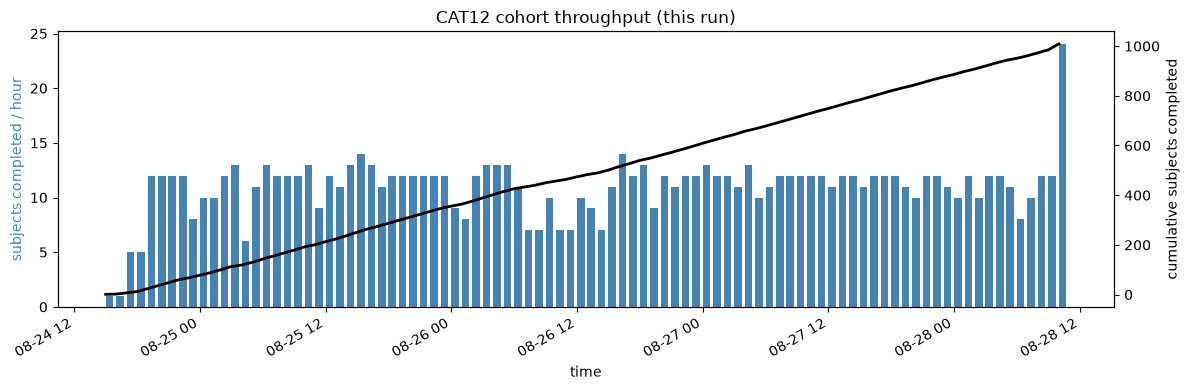

In [6]:
hourly = runs_this_run.set_index("last_modified").resample("1h").size()
cumulative = hourly.cumsum()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(hourly.index, hourly.values, width=0.03, align="edge", color="steelblue", label="per hour")
ax1.set_ylabel("subjects completed / hour", color="steelblue")
ax1.set_xlabel("time")

ax2 = ax1.twinx()
ax2.plot(cumulative.index, cumulative.values, color="black", lw=2, label="cumulative")
ax2.set_ylabel("cumulative subjects completed")

fig.autofmt_xdate()
plt.title("CAT12 cohort throughput (this run)")
plt.tight_layout()


## 5. Recent rate (rolling window)

Even §3's whole-run rate averages over the run so far, which can hide a
recent slowdown/speedup. This uses only the last `window_hours` of
completions for a more current estimate — more useful for an ETA the longer
the run has been going.


In [7]:
window_hours = 3

cutoff = runs_this_run["last_modified"].max() - pd.Timedelta(hours=int(window_hours))
recent = runs_this_run[runs_this_run["last_modified"] >= cutoff]
if len(recent) >= 2:
    recent_span_hours = (recent["last_modified"].max() - recent["last_modified"].min()).total_seconds() / 3600
    recent_rate = len(recent) / max(recent_span_hours, 1e-6)
    print(f"last {window_hours}h: {len(recent)} subjects, "
          f"~{recent_rate:.2f} subjects/hour ({recent_rate * 24:.0f}/day)")
else:
    print(f"fewer than 2 completions in the last {window_hours}h — widen window_hours")


last 3h: 48 subjects, ~17.25 subjects/hour (414/day)


/tmp/ipykernel_1414590/1769043244.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  cutoff = runs_this_run["last_modified"].max() - pd.Timedelta(hours=int(window_hours))


## 6. Cross-check against the ledger

`bagpipe.preprocess.cat12_cohort`'s own ledger records `updated_at` per
subject when the *driver* marks it succeeded — should track closely with
this notebook's filesystem-mtime estimate but isn't identical (driver marks
succeeded only after the whole job returns, filesystem mtime reflects the
last file CAT12 itself wrote — driver's timestamp is always slightly later).
A large, growing gap between the two would be worth investigating.


In [8]:
if ledger_path.exists():
    ledger = pd.read_sql(
        "select t1w_path, status, attempts, updated_at from subjects where status='succeeded'",
        con,
    )
    ledger["updated_at"] = pd.to_datetime(ledger["updated_at"], utc=True).dt.tz_localize(None)
    print(f"ledger: {len(ledger)} succeeded subjects, "
          f"latest updated_at: {ledger['updated_at'].max()}")
    print(f"this notebook (this run): {len(runs_this_run)} subject/session dirs with output, "
          f"latest last_modified: {runs_this_run['last_modified'].max()}")
else:
    print("no ledger found at", ledger_path)


ledger: 937 succeeded subjects, latest updated_at: 2026-08-28 07:57:17.303508
this notebook (this run): 1009 subject/session dirs with output, latest last_modified: 2026-08-28 10:59:29.265471
